In [2]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#——————————————————————————————核心激活函数与网络构建——————————————————————————

# ———————————————————————————— 1. 激活函数 ——————————————————————————
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_derivative(z): s = sigmoid(z); return s * (1 - s)
def linear(z): return z
def linear_derivative(z): return np.ones_like(z)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
def softmax_derivative(z): return None # 梯度通过交叉熵结合直接计算

# ———————————————————————————— 2. 全连接层 ——————————————————————————
class FullyConnectedLayer:
    def __init__(self, input_dim, output_dim, activation='relu', dim_output=False):
        self.input_dim, self.output_dim, self.dim_output = input_dim, output_dim, dim_output
        self.Z, self.A_in, self.A_out = None, None, None
        
        # He initialization
        self.W = np.random.randn(input_dim, output_dim) * (1.0 / np.sqrt(input_dim))
        self.b = np.zeros((1, output_dim))
       
        activations = {'relu': (relu, relu_derivative), 'sigmoid': (sigmoid, sigmoid_derivative),
                       'softmax': (softmax, softmax_derivative), 'linear': (linear, linear_derivative)}
        self.activation, self.activation_deriv = activations.get(activation, activations['linear'])

    def forward(self, A_in):
        self.A_in = A_in
        self.Z = self.A_in @ self.W + self.b
        self.A_out = self.activation(self.Z)
        self.print_dims("Forward pass", self.Z, self.A_in, self.A_out)
        return self.A_out

    def backward(self, dA_out, y_true=None, is_output_layer=False):
        if is_output_layer:
            dZ = self.A_out - y_true.reshape(self.A_out.shape)
        else:
            dZ = dA_out * self.activation_deriv(self.Z)
        
        N = dZ.shape[0]
        dW = (self.A_in.T @ dZ) / N
        db = np.sum(dZ, axis=0, keepdims=True) / N
        dA_in = dZ @ self.W.T
        
        self.print_dims("Backward pass", dZ, dW, db, dA_in)
        return dA_in, dW, db
        
    def print_dims(self, label, *args):
        if self.dim_output:
            print(f"{label}: ", " ".join(str(a.shape) for a in args))

# ———————————————————————————— 3. 神经网络类 ——————————————————————————
class NeuralNetwork:
    def __init__(self, layers_config):
        self.layers = [FullyConnectedLayer(in_dim, out_dim, act) for in_dim, out_dim, act in layers_config]
    
    def forward(self, X):
        A = X
        for layer in self.layers: A = layer.forward(A)
        return A
    
    def backward(self, dA, y_true):
        grads = []
        for i, layer in reversed(list(enumerate(self.layers))):
            dA, dW, db = layer.backward(dA_out=dA, y_true=y_true, is_output_layer=(i == len(self.layers)-1))
            grads.append((dW, db))
        grads.reverse()
        return grads
    
    def update_params(self, grads, lr=0.001):
        for layer, (dW, db) in zip(self.layers, grads):
            layer.W -= lr * dW; layer.b -= lr * db

    def save_model(self, file_path):
        model_data = {
            "layers_config": [(l.W.shape[0], l.W.shape[1], l.activation.__name__) for l in self.layers],
            "weights": [l.W for l in self.layers], "biases": [l.b for l in self.layers]
        }
        with open(file_path, 'wb') as f: pickle.dump(model_data, f)
        print(f"Model saved to {file_path}")

    @staticmethod
    def load_model(file_path):
        with open(file_path, 'rb') as f: model_data = pickle.load(f)
        nn = NeuralNetwork(model_data["layers_config"])
        for layer, W, b in zip(nn.layers, model_data["weights"], model_data["biases"]):
            layer.W, layer.b = W, b
        print(f"Model loaded from {file_path}")
        return nn

In [3]:
#——————————————————————————————数据处理与评估指标————————————————————————————
# ———————————————————————————— 1. 数据读取与通用划分逻辑 ——————————————————————————
def read_mnist_csv(csv_file, target_labels=None):
    df = pd.read_csv(csv_file, header=None)
    labels, X = df.iloc[:, 0].values, df.iloc[:, 1:].values.astype(np.float32) / 255.0

    if target_labels is not None:
        mask = np.isin(labels, target_labels)
        X, labels = X[mask], labels[mask]
    
    y = np.eye(10)[labels] # One-hot
    return X, y, labels

def _shuffle_and_split(X, y, labels, train_ratio, data_use_ratio):
    indices = np.random.permutation(len(X))
    X, y, labels = X[indices], y[indices], labels[indices]
    
    use_num = int(len(X) * data_use_ratio)
    train_end = int(train_ratio * use_num)
    
    print(f"Train X: {X[:train_end].shape} | Train Y: {y[:train_end].shape}")
    print(f"Test X:  {X[train_end:use_num].shape} | Test Y:  {y[train_end:use_num].shape}")
    print(f"Unique labels: {np.unique(labels)} | Total samples: {len(labels)} | Classes: {len(np.unique(labels))}")
    return X[:train_end], y[:train_end], X[train_end:use_num], y[train_end:use_num]

def prepare_binary_data(csv_file, target_labels, train_ratio=0.8, data_use_ratio=1.0):
    X, _, labels = read_mnist_csv(csv_file, target_labels=target_labels)
    y = (labels == target_labels[1]).astype(int).reshape(-1, 1)
    return _shuffle_and_split(X, y, labels, train_ratio, data_use_ratio)

def prepare_multi_data(csv_file, train_ratio=0.8, data_use_ratio=1.0):
    X, y, labels = read_mnist_csv(csv_file)
    return _shuffle_and_split(X, y, labels, train_ratio, data_use_ratio)

# ———————————————————————————— 2. 损失函数与准确率 ——————————————————————————
def binary_cross_entropy_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_binary_accuracy(y_pred, y_true):
    return np.mean((y_pred > 0.5).astype(int).flatten() == y_true.flatten())

def softmax_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def compute_multi_accuracy(y_pred, y_true):
    return np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

In [4]:
# ———————————————————————————————训练与可视化——————————————————————————————————
# ———————————————————————————— 1. 训练核心模块封装 ——————————————————————————
def _train_minibatch_core(model, X_train, y_train, lr, max_epoch, batch_size, loss_fn, acc_fn):
    for layer in model.layers: layer.dim_output = False
    loss_history = []
    n_samples = X_train.shape[0]
    
    for epoch in range(max_epoch):
        indices = np.random.permutation(n_samples)
        X_shuf, y_shuf = X_train[indices], y_train[indices]
        
        for i in range(0, n_samples, batch_size):
            X_batch, y_batch = X_shuf[i:i+batch_size], y_shuf[i:i+batch_size]
            grads = model.backward(dA=model.forward(X_batch), y_true=y_batch)
            model.update_params(grads, lr=lr)
            
        y_pred_full = model.forward(X_train)
        current_loss = loss_fn(y_pred_full, y_train)
        loss_history.append(current_loss)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{max_epoch} | Loss: {current_loss:.4f} | Train Acc: {acc_fn(y_pred_full, y_train)*100:.2f}%")
            
    return loss_history

def train_network_minibatch(model, X_train, y_train, lr=0.01, max_epoch=50, batch_size=64):
    return _train_minibatch_core(model, X_train, y_train, lr, max_epoch, batch_size, binary_cross_entropy_loss, compute_binary_accuracy)

def train_network_multiclass(model, X_train, y_train, lr=0.01, max_epoch=30, batch_size=64):
    return _train_minibatch_core(model, X_train, y_train, lr, max_epoch, batch_size, softmax_loss, compute_multi_accuracy)

# ———————————————————————————— 2. 可视化模块 ——————————————————————————
def draw_prediction_examples(model, X_test, y_test, target_labels):
    y_pred = (model.forward(X_test) > 0.5).astype(int).flatten()
    y_true = y_test.flatten()
    
    def plot_samples(indices, title):
        if len(indices) == 0: return
        fig, axes = plt.subplots(1, min(3, len(indices)), figsize=(9, 3))
        if len(indices) == 1: axes = [axes]
        for i, idx in enumerate(indices[:3]):
            axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
            t_digit = target_labels[1] if y_true[idx] == 1 else target_labels[0]
            p_digit = target_labels[1] if y_pred[idx] == 1 else target_labels[0]
            axes[i].set_title(f"True: {t_digit} | Pred: {p_digit}"); axes[i].axis('off')
        plt.suptitle(title); plt.show()

    plot_samples(np.where(y_pred == y_true)[0], "Correct Predictions")
    plot_samples(np.where(y_pred != y_true)[0], "Incorrect Predictions")

def draw_multiclass_prediction_examples(model, X_test, y_test, seed=42):
    np.random.seed(seed)
    y_pred, y_true = np.argmax(model.forward(X_test), axis=1), np.argmax(y_test, axis=1)
    
    def plot_grid(indices, title, color):
        fig, axes = plt.subplots(2, 5, figsize=(12, 5))
        for i, ax in enumerate(axes.flatten()):
            class_indices = indices[y_true[indices] == i]
            if len(class_indices) > 0:
                idx = np.random.choice(class_indices)
                ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
                ax.set_title(f"True: {i} | Pred: {y_pred[idx]}", color=color)
            ax.axis('off')
        plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

    plot_grid(np.where(y_pred == y_true)[0], "Correct Predictions (One per Digit)", "green")
    plot_grid(np.where(y_pred != y_true)[0], "Incorrect Predictions (One per Digit)", "red")


Task: Binary Classification for 1 vs 7
Train X: (10405, 784) | Train Y: (10405, 1)
Test X:  (2602, 784) | Test Y:  (2602, 1)
Unique labels: [1 7] | Total samples: 13007 | Classes: 2

>>> Training Baseline Model: [128, 64] Hidden Nodes
Epoch   1/30 | Loss: 0.0384 | Train Acc: 98.97%
Epoch   5/30 | Loss: 0.0155 | Train Acc: 99.53%
Epoch  10/30 | Loss: 0.0108 | Train Acc: 99.67%
Epoch  15/30 | Loss: 0.0079 | Train Acc: 99.77%
Epoch  20/30 | Loss: 0.0062 | Train Acc: 99.80%
Epoch  25/30 | Loss: 0.0057 | Train Acc: 99.83%
Epoch  30/30 | Loss: 0.0039 | Train Acc: 99.88%
Baseline Training Time: 2.97s | Test Accuracy: 99.58%

>>> Visualizing Results...


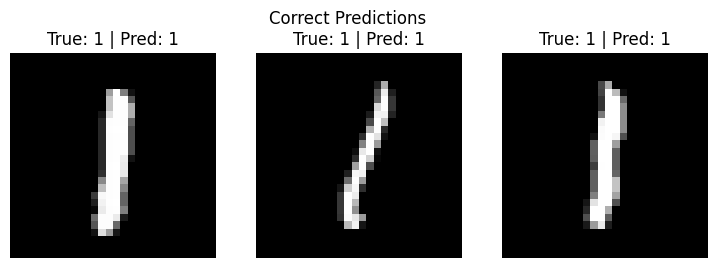

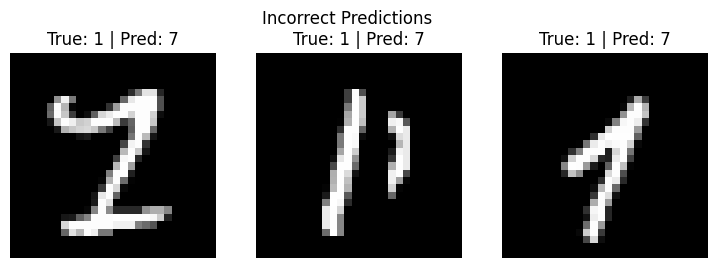


Task: Binary Classification for 3 vs 5
Train X: (9241, 784) | Train Y: (9241, 1)
Test X:  (2311, 784) | Test Y:  (2311, 1)
Unique labels: [3 5] | Total samples: 11552 | Classes: 2

>>> Training Baseline Model: [128, 64] Hidden Nodes
Epoch   1/30 | Loss: 0.1726 | Train Acc: 93.11%
Epoch   5/30 | Loss: 0.0615 | Train Acc: 97.88%
Epoch  10/30 | Loss: 0.0523 | Train Acc: 98.02%
Epoch  15/30 | Loss: 0.0172 | Train Acc: 99.61%
Epoch  20/30 | Loss: 0.0103 | Train Acc: 99.84%
Epoch  25/30 | Loss: 0.0059 | Train Acc: 99.96%
Epoch  30/30 | Loss: 0.0036 | Train Acc: 99.98%
Baseline Training Time: 2.52s | Test Accuracy: 98.70%

>>> Visualizing Results...


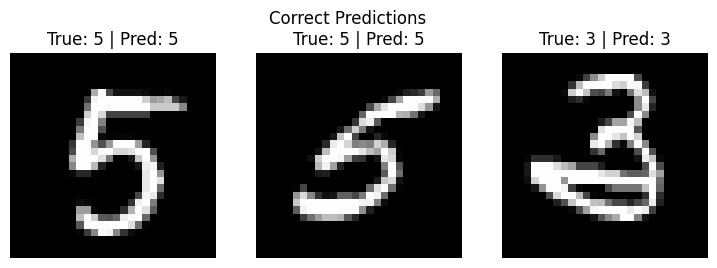

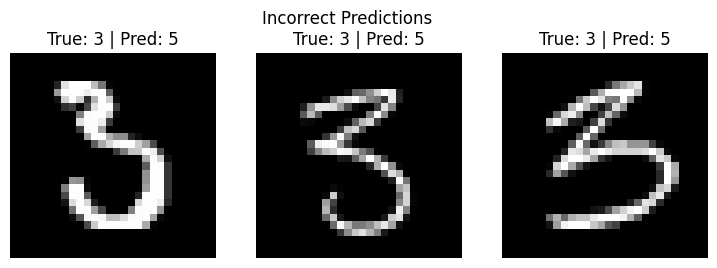


Task: Binary Classification for 4 vs 9
Train X: (9432, 784) | Train Y: (9432, 1)
Test X:  (2359, 784) | Test Y:  (2359, 1)
Unique labels: [4 9] | Total samples: 11791 | Classes: 2

>>> Training Baseline Model: [128, 64] Hidden Nodes
Epoch   1/30 | Loss: 0.1477 | Train Acc: 95.25%
Epoch   5/30 | Loss: 0.0823 | Train Acc: 97.18%
Epoch  10/30 | Loss: 0.0322 | Train Acc: 98.99%
Epoch  15/30 | Loss: 0.0370 | Train Acc: 98.70%
Epoch  20/30 | Loss: 0.0109 | Train Acc: 99.87%
Epoch  25/30 | Loss: 0.0070 | Train Acc: 99.94%
Epoch  30/30 | Loss: 0.0161 | Train Acc: 99.39%
Baseline Training Time: 2.61s | Test Accuracy: 98.09%

>>> Visualizing Results...


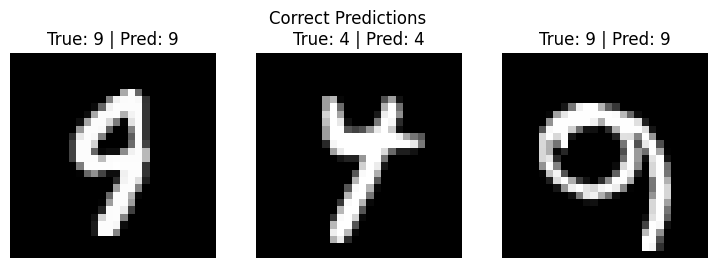

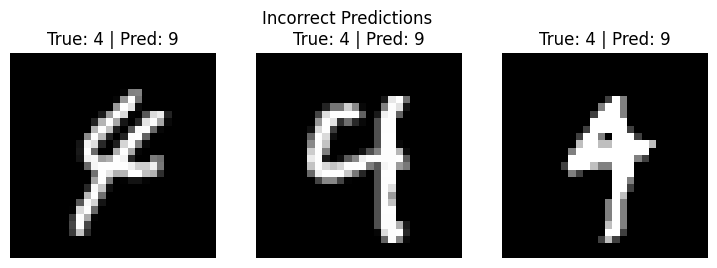

In [5]:
#————————————————————————————二分类 Baseline 测试 (Task 1)————————————————————————————
csv_file = "../mnist.csv" 
target_labels_list = [[1, 7], [3, 5], [4, 9]]
layers_config_baseline = [(784, 128, 'relu'), (128, 64, 'relu'), (64, 1, 'sigmoid')]

for target_labels in target_labels_list:
    print(f"\n{'='*50}\nTask: Binary Classification for {target_labels[0]} vs {target_labels[1]}")
    train_x, train_y, test_x, test_y = prepare_binary_data(csv_file, target_labels, data_use_ratio=1.0)
    
    print("\n>>> Training Baseline Model: [128, 64] Hidden Nodes")
    model_baseline = NeuralNetwork(layers_config_baseline)
    
    t0 = time.time()
    train_network_minibatch(model_baseline, train_x, train_y, lr=0.05, max_epoch=30, batch_size=64)
    time_cost = time.time() - t0
    
    test_acc = compute_binary_accuracy(model_baseline.forward(test_x), test_y)
    print(f"Baseline Training Time: {time_cost:.2f}s | Test Accuracy: {test_acc*100:.2f}%\n")
    
    print(">>> Visualizing Results...")
    draw_prediction_examples(model_baseline, test_x, test_y, target_labels)

In [6]:
# —————————————————————————二分类不同网络架构横向对比——————————————————————
model_archs = {
    "1. Shallow & Narrow": [(784, 16, 'relu'), (16, 1, 'sigmoid')],
    "2. Shallow & Wide": [(784, 256, 'relu'), (256, 1, 'sigmoid')],
    "3. Baseline (Moderate)": [(784, 128, 'relu'), (128, 64, 'relu'), (64, 1, 'sigmoid')],
    "4. Deep": [(784, 128, 'relu'), (128, 64, 'relu'), (64, 32, 'relu'), (32, 16, 'relu'), (16, 1, 'sigmoid')],
    "5. Overly Deep": [(784, 512, 'relu'), (512, 256, 'relu'), (256, 128, 'relu'), 
                       (128, 64, 'relu'), (64, 32, 'relu'), (32, 16, 'relu'), (16, 1, 'sigmoid')]
}

print("=== 模型结构对训练速度与准确率的影响分析 ===\n")
target_labels = [4, 9]
print(f"Task: Binary Classification for {target_labels[0]} vs {target_labels[1]}")
train_x, train_y, test_x, test_y = prepare_binary_data(csv_file, target_labels, data_use_ratio=1.0)

for name, config in model_archs.items():
    print(f"\n正在训练模型: {name}\n网络层级: {config}")
    model = NeuralNetwork(config)
    
    t0 = time.time()
    train_network_minibatch(model, train_x, train_y, lr=0.05, max_epoch=30, batch_size=64)
    time_cost = time.time() - t0
    
    test_acc = compute_binary_accuracy(model.forward(test_x), test_y)
    print(f"--> 训练耗时: {time_cost:.2f} 秒\n--> 预测准确率: {test_acc*100:.2f}%\n" + "-" * 50)

=== 模型结构对训练速度与准确率的影响分析 ===

Task: Binary Classification for 4 vs 9
Train X: (9432, 784) | Train Y: (9432, 1)
Test X:  (2359, 784) | Test Y:  (2359, 1)
Unique labels: [4 9] | Total samples: 11791 | Classes: 2

正在训练模型: 1. Shallow & Narrow
网络层级: [(784, 16, 'relu'), (16, 1, 'sigmoid')]
Epoch   1/30 | Loss: 0.1560 | Train Acc: 95.25%
Epoch   5/30 | Loss: 0.0960 | Train Acc: 96.73%
Epoch  10/30 | Loss: 0.0886 | Train Acc: 96.84%
Epoch  15/30 | Loss: 0.0793 | Train Acc: 97.32%
Epoch  20/30 | Loss: 0.0676 | Train Acc: 97.81%
Epoch  25/30 | Loss: 0.0540 | Train Acc: 98.17%
Epoch  30/30 | Loss: 0.0448 | Train Acc: 98.44%
--> 训练耗时: 1.21 秒
--> 预测准确率: 97.71%
--------------------------------------------------

正在训练模型: 2. Shallow & Wide
网络层级: [(784, 256, 'relu'), (256, 1, 'sigmoid')]
Epoch   1/30 | Loss: 0.1606 | Train Acc: 95.08%
Epoch   5/30 | Loss: 0.0909 | Train Acc: 97.14%
Epoch  10/30 | Loss: 0.0697 | Train Acc: 97.76%
Epoch  15/30 | Loss: 0.0546 | Train Acc: 98.29%
Epoch  20/30 | Loss: 0.0435 


========== Task 1: 10-Class MNIST Classification ==========
Train X: (48000, 784) | Train Y: (48000, 10)
Test X:  (12000, 784) | Test Y:  (12000, 10)
Unique labels: [0 1 2 3 4 5 6 7 8 9] | Total samples: 60000 | Classes: 10
Epoch   1/40 | Loss: 0.2916 | Train Acc: 91.70%
Epoch   5/40 | Loss: 0.1184 | Train Acc: 96.56%
Epoch  10/40 | Loss: 0.0585 | Train Acc: 98.35%
Epoch  15/40 | Loss: 0.0341 | Train Acc: 99.10%
Epoch  20/40 | Loss: 0.0209 | Train Acc: 99.52%
Epoch  25/40 | Loss: 0.0123 | Train Acc: 99.78%
Epoch  30/40 | Loss: 0.0068 | Train Acc: 99.96%
Epoch  35/40 | Loss: 0.0045 | Train Acc: 99.99%
Epoch  40/40 | Loss: 0.0032 | Train Acc: 100.00%
---> 10 分类模型训练完毕！耗时: 17.87s
---> 最终测试集准确率: 97.68%

>>> Visualizing Multi-Class Results...


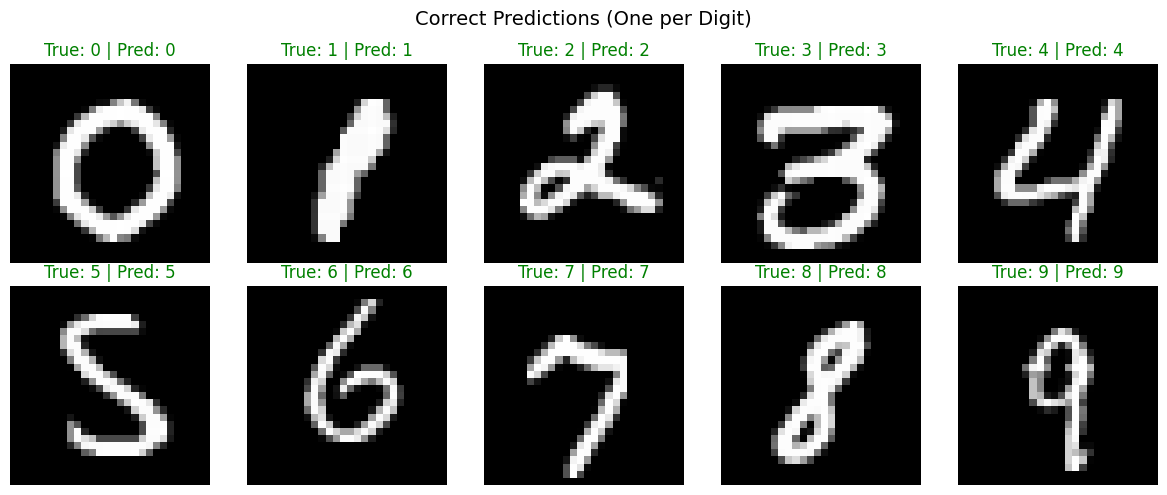

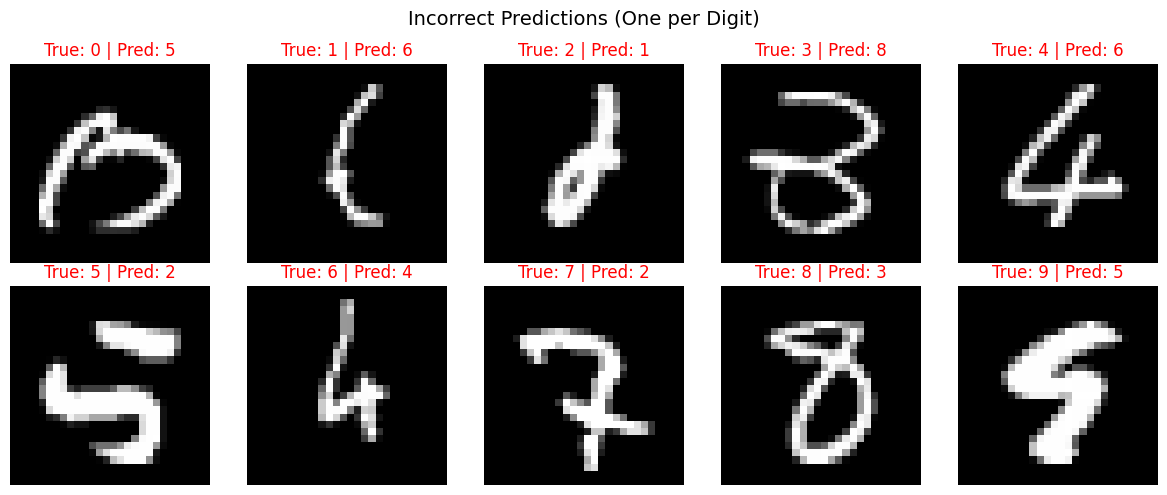

In [ ]:
#————————————————————————十分多分类、预测可视化——————————————————
print("\n========== Task 1: 10-Class MNIST Classification ==========")
train_x_multi, train_y_multi, test_x_multi, test_y_multi = prepare_multi_data(csv_file)

layers_config_multi = [(784, 128, 'relu'), (128, 64, 'relu'), (64, 10, 'softmax')]
model_multi = NeuralNetwork(layers_config_multi)

t0 = time.time()
train_network_multiclass(model_multi, train_x_multi, train_y_multi, lr=0.05, max_epoch=40, batch_size=64)
print(f"---> 10 分类模型训练完毕！耗时: {time.time() - t0:.2f}s")

test_acc_multi = compute_multi_accuracy(model_multi.forward(test_x_multi), test_y_multi)
print(f"---> 最终测试集准确率: {test_acc_multi*100:.2f}%\n")

print(">>> Visualizing Multi-Class Results...")
draw_multiclass_prediction_examples(model_multi, test_x_multi, test_y_multi)

In [9]:
#——————————————————————-模型保存加载——————————————————————————
print("\n----------- 模型保存与加载验证 -------------")
model_save_path = "mnist_trained_model.pkl"
model_multi.save_model(model_save_path)

model_path = "mnist_trained_model.pkl"
load_nn = NeuralNetwork.load_model(model_path)
loaded_acc = compute_multi_accuracy(load_nn.forward(test_x_multi), test_y_multi)
print(f"加载后的模型在测试集上的准确率为: {loaded_acc*100:.2f}%")


----------- 模型保存与加载验证 -------------
Model saved to mnist_trained_model.pkl
Model loaded from mnist_trained_model.pkl
加载后的模型在测试集上的准确率为: 97.68%
